In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import numpy as np
import argparse
import matplotlib.gridspec as gridspec
import geopandas as gpd
from shapely.geometry import Point, Polygon
from matplotlib import font_manager

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 # Also recommended for PostScript output



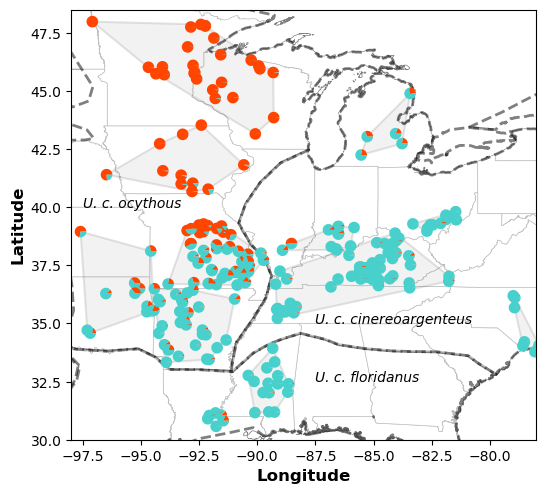

In [9]:
q_matrix_path = '../data/structure/q_matrix_2'
meta_path = '../config/meta_apriori_jittered.csv' 
bam_path = '../data/merged_bams/bams_4_rcr.txt'
geno_path = "../data/genotypes/genotype_matrix.csv"


fig, ax = plt.subplots(figsize=(6,6))
k = 2
usa_shapefile = gpd.read_file(r'../data/shapefiles/s_08mr23.shp')
subspecies_shapefile = gpd.read_file(r'../data/shapefiles/subspecies_22780.shp')

colors = ['orangered', 'mediumturquoise', 'black', 'gold','magenta',
            'orange', 'red', 'aqua', 'hotpink', 'lime', 'blue']
    
qmatrix = pd.read_csv(q_matrix_path, index_col=0)

bam = pd.read_table(bam_path, header=None)
bam.columns = ['Sample_ID']
bam['Sample_ID'] = bam['Sample_ID'].apply(lambda x: x.split('/')[-1].split('.')[0])

qmatrix = pd.merge(qmatrix, bam, left_index=True, right_index=True)

meta = pd.read_csv(meta_path)
qmatrix = pd.merge(qmatrix, meta, left_on='Sample_ID', right_on='Sample_ID')

usa_shapefile.plot(ax=ax, facecolor='White', edgecolor='gray', linewidth=0.5, rasterized=True)
subspecies_shapefile.plot(ax=ax, facecolor='White', edgecolor='black', linewidth=2, linestyle='--', alpha=0.5, rasterized=True)

# Plotting apriori pops
for population, group in qmatrix.groupby('POP'):
    points = [Point(lon, lat) for lon, lat in zip(group['longitude'], group['latitude'])]
    poly = gpd.GeoSeries(points).union_all().convex_hull
    x, y = poly.exterior.xy
    ax.fill(x, y, edgecolor='black', facecolor='gray', linewidth=1.5, alpha = 0.1)

ax.set_ylim([30, 48.5])
ax.set_xlim([-98, -78])

ax.set_xlabel('Longitude', fontweight='bold', fontsize=12)
ax.set_ylabel('Latitude', fontweight='bold', fontsize=12)

ax.text(-97.5, 40, 'U. c. ocythous', fontsize=10, fontstyle='italic')
ax.text(-87.5, 32.5, 'U. c. floridanus', fontsize=10, fontstyle='italic')
ax.text(-87.5, 35.0, 'U. c. cinereoargenteus', fontsize=10, fontstyle='italic')

for idx, row in qmatrix.iterrows():
    proportions = row[1:k+1]
    wedges, _ = ax.pie(
    proportions,
    colors=colors,
    radius=0.25,
    center=(row['longitude'], row['latitude']),
    wedgeprops={'clip_on': True},
    frame=True
)

    # Rasterize all wedges
    for w in wedges:
        w.set_rasterized(True)


plt.savefig('../PieMap_k2.pdf',dpi=300, bbox_inches='tight', pad_inches=0.02,
            transparent=False)
plt.show()

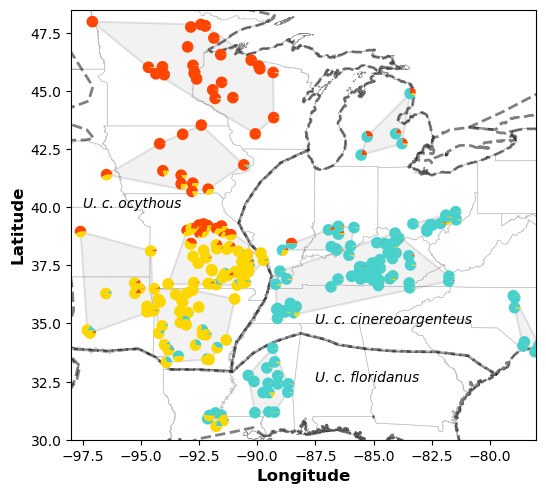

In [4]:
q_matrix_path = '../data/structure/q_matrix_3'
meta_path = '../config/meta_apriori_jittered.csv' 
bam_path = '../data/merged_bams/bams_4_rcr.txt'
geno_path = "../data/genotypes/genotype_matrix.csv"


fig, ax = plt.subplots(figsize=(6,6))
k = 3
usa_shapefile = gpd.read_file(r'../data/shapefiles/s_08mr23.shp')
subspecies_shapefile = gpd.read_file(r'../data/shapefiles/subspecies_22780.shp')

colors = ['orangered', 'mediumturquoise', 'gold', 'gold','magenta',
            'orange', 'red', 'aqua', 'hotpink', 'lime', 'blue']
    
qmatrix = pd.read_csv(q_matrix_path, index_col=0)

bam = pd.read_table(bam_path, header=None)
bam.columns = ['Sample_ID']
bam['Sample_ID'] = bam['Sample_ID'].apply(lambda x: x.split('/')[-1].split('.')[0])

qmatrix = pd.merge(qmatrix, bam, left_index=True, right_index=True)

meta = pd.read_csv(meta_path)
qmatrix = pd.merge(qmatrix, meta, left_on='Sample_ID', right_on='Sample_ID')

usa_shapefile.plot(ax=ax, facecolor='White', edgecolor='gray', linewidth=0.5, rasterized=True)
subspecies_shapefile.plot(ax=ax, facecolor='White', edgecolor='black', linewidth=2, linestyle='--', alpha=0.5, rasterized=True)

# Plotting apriori pops
for population, group in qmatrix.groupby('POP'):
    points = [Point(lon, lat) for lon, lat in zip(group['longitude'], group['latitude'])]
    poly = gpd.GeoSeries(points).union_all().convex_hull
    x, y = poly.exterior.xy
    ax.fill(x, y, edgecolor='black', facecolor='gray', linewidth=1.5, alpha = 0.1)

ax.set_ylim([30, 48.5])
ax.set_xlim([-98, -78])

ax.set_xlabel('Longitude', fontweight='bold', fontsize=12)
ax.set_ylabel('Latitude', fontweight='bold', fontsize=12)

ax.text(-97.5, 40, 'U. c. ocythous', fontsize=10, fontstyle='italic')
ax.text(-87.5, 32.5, 'U. c. floridanus', fontsize=10, fontstyle='italic')
ax.text(-87.5, 35.0, 'U. c. cinereoargenteus', fontsize=10, fontstyle='italic')

for idx, row in qmatrix.iterrows():
    proportions = row[1:k+1]
    wedges, _ = ax.pie(
    proportions,
    colors=colors,
    radius=0.25,
    center=(row['longitude'], row['latitude']),
    wedgeprops={'clip_on': True},
    frame=True
)

    # Rasterize all wedges
    for w in wedges:
        w.set_rasterized(True)


plt.savefig('../PieMap_k3.pdf',dpi=300, bbox_inches='tight', pad_inches=0.02,
            transparent=False)
plt.show()

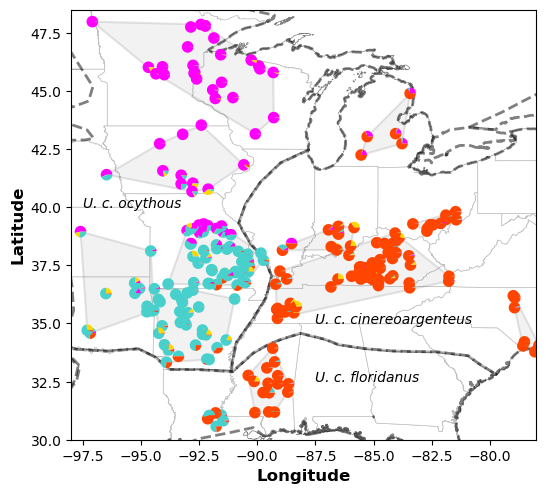

In [3]:
q_matrix_path = '../data/structure/q_matrix_4'
meta_path = '../config/meta_apriori_jittered.csv' 
bam_path = '../data/merged_bams/bams_4_rcr.txt'
geno_path = "../data/genotypes/genotype_matrix.csv"


fig, ax = plt.subplots(figsize=(6,6))
k = 4
usa_shapefile = gpd.read_file(r'../data/shapefiles/s_08mr23.shp')
subspecies_shapefile = gpd.read_file(r'../data/shapefiles/subspecies_22780.shp')

colors = ['magenta',  'gold', 'mediumturquoise','orangered']
    
qmatrix = pd.read_csv(q_matrix_path, index_col=0)

bam = pd.read_table(bam_path, header=None)
bam.columns = ['Sample_ID']
bam['Sample_ID'] = bam['Sample_ID'].apply(lambda x: x.split('/')[-1].split('.')[0])

qmatrix = pd.merge(qmatrix, bam, left_index=True, right_index=True)

meta = pd.read_csv(meta_path)
qmatrix = pd.merge(qmatrix, meta, left_on='Sample_ID', right_on='Sample_ID')

usa_shapefile.plot(ax=ax, facecolor='White', edgecolor='gray', linewidth=0.5, rasterized=True)
subspecies_shapefile.plot(ax=ax, facecolor='White', edgecolor='black', linewidth=2, linestyle='--', alpha=0.5, rasterized=True)

# Plotting apriori pops
for population, group in qmatrix.groupby('POP'):
    points = [Point(lon, lat) for lon, lat in zip(group['longitude'], group['latitude'])]
    poly = gpd.GeoSeries(points).union_all().convex_hull
    x, y = poly.exterior.xy
    ax.fill(x, y, edgecolor='black', facecolor='gray', linewidth=1.5, alpha = 0.1)

ax.set_ylim([30, 48.5])
ax.set_xlim([-98, -78])

ax.set_xlabel('Longitude', fontweight='bold', fontsize=12)
ax.set_ylabel('Latitude', fontweight='bold', fontsize=12)

ax.text(-97.5, 40, 'U. c. ocythous', fontsize=10, fontstyle='italic')
ax.text(-87.5, 32.5, 'U. c. floridanus', fontsize=10, fontstyle='italic')
ax.text(-87.5, 35.0, 'U. c. cinereoargenteus', fontsize=10, fontstyle='italic')

for idx, row in qmatrix.iterrows():
    proportions = row[1:k+1]
    wedges, _ = ax.pie(
    proportions,
    colors=colors,
    radius=0.25,
    center=(row['longitude'], row['latitude']),
    wedgeprops={'clip_on': True},
    frame=True
)

    # Rasterize all wedges
    for w in wedges:
        w.set_rasterized(True)


plt.savefig('../PieMap_k4.pdf',dpi=300, bbox_inches='tight', pad_inches=0.02,
            transparent=False)
plt.show()